In [ ]:
### Multiple Linear Regression

In [ ]:
# problem statement
# predict profit of a company base on RnD, Administrative and Marketing budget and State

In [ ]:
### import required packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
### load the data

In [8]:
df = pd.read_csv("C:\\Users\\sainya.vishwakarma\\Python\\ML3\\50_Startups.csv")
df

,RnD,Administration,Marketing,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94
5,131876.90,99814.71,362861.36,New York,156991.12
6,134615.46,147198.87,127716.82,California,156122.51
7,130298.13,145530.06,323876.68,Florida,155752.60
8,120542.52,148718.95,311613.29,New York,152211.77
9,123334.88,108679.17,304981.62,California,149759.96


In [ ]:
### elaboratory data analysis

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   RnD             50 non-null     float64
 1   Administration  50 non-null     float64
 2   Marketing       50 non-null     float64
 3   State           50 non-null     str    
 4   Profit          50 non-null     float64
dtypes: float64(4), str(1)
memory usage: 2.1 KB


In [10]:
df.isna().sum()

RnD               0
Administration    0
Marketing         0
State             0
Profit            0
dtype: int64

In [ ]:
### get statstical info of data

In [11]:
df.describe()

,RnD,Administration,Marketing,Profit
count,50.000000,50.000000,50.000000,50.000000
mean,73721.615600,121344.639600,211025.097800,112012.639200
std,45902.256482,28017.802755,122290.310726,40306.180338
min,0.000000,51283.140000,0.000000,14681.400000
25%,39936.370000,103730.875000,129300.132500,90138.902500
50%,73051.080000,122699.795000,212716.240000,107978.190000
75%,101602.800000,144842.180000,299469.085000,139765.977500
max,165349.200000,182645.560000,471784.100000,192261.830000


In [20]:
from sklearn.preprocessing import LabelEncoder

# label encoder encodes the textual value by replacing them with a numeric value
# - get all unique values
# - arrange them in ascending order
# - keep replacing them with their index positions

# create a labelEncoder object
encoder = LabelEncoder()

# fit the data to be encoded
# classes = ['California', 'florida', 'New York']
encoder.fit(df['State'])
# convert the categorical state data to numeric
df['State'] = encoder.transform(df['State'])
df

,RnD,Administration,Marketing,State,Profit
0,165349.20,136897.80,471784.10,2,192261.83
1,162597.70,151377.59,443898.53,0,191792.06
2,153441.51,101145.55,407934.54,1,191050.39
3,144372.41,118671.85,383199.62,2,182901.99
4,142107.34,91391.77,366168.42,1,166187.94
5,131876.90,99814.71,362861.36,2,156991.12
6,134615.46,147198.87,127716.82,0,156122.51
7,130298.13,145530.06,323876.68,1,155752.60
8,120542.52,148718.95,311613.29,2,152211.77
9,123334.88,108679.17,304981.62,0,149759.96


In [21]:
df.corr()

,RnD,Administration,Marketing,State,Profit
RnD,1.000000,0.241955,0.724248,0.104685,0.972900
Administration,0.241955,1.000000,-0.032154,0.011847,0.200717
Marketing,0.724248,-0.032154,1.000000,0.077670,0.747766
State,0.104685,0.011847,0.077670,1.000000,0.101796
Profit,0.972900,0.200717,0.747766,0.101796,1.000000


In [22]:
encoder.classes_

array([0, 1, 2])

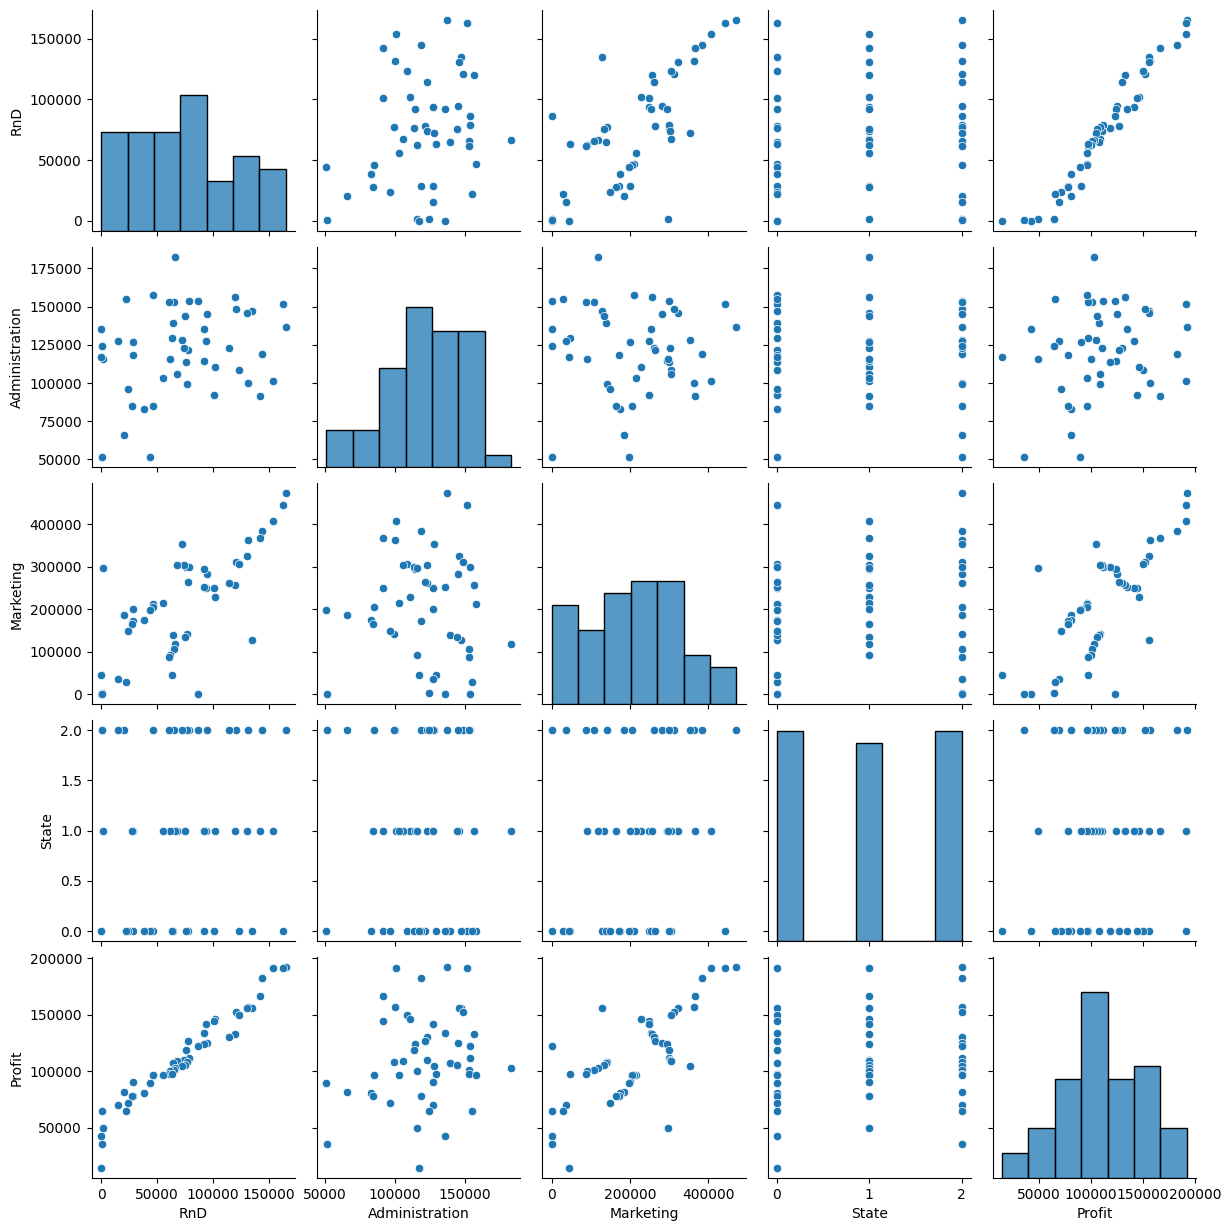

In [23]:
# show pair plots of the datasets

sns.pairplot(df)

In [ ]:
### split the data into x and y

In [25]:
x = df.drop(['Profit','State','Administration'], axis =1)
y = df['Profit']

In [ ]:
### split the data into train and test dataset

In [29]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,train_size=0.8,random_state=2)

In [ ]:
### train the model

In [38]:
from sklearn.linear_model import LinearRegression

# create the model

model = LinearRegression()

# fit the model

model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[0.79,0.03]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['RnD','Marketing']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.698e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,2


In [ ]:
### evaluate the model on training set

In [40]:
from sklearn.metrics import mean_absolute_error,mean_absolute_percentage_error,mean_squared_error,root_mean_squared_error,r2_score

# predict the x_train
y_pred = model.predict(x_train)

mae = mean_absolute_error(y_train,y_pred)
mape = mean_absolute_percentage_error(y_train,y_pred)
mse = mean_squared_error(y_train,y_pred)
rmse = root_mean_squared_error(y_train,y_pred)
r2s = r2_score(y_train,y_pred)

print(f"mean absolute error : {mae:.2f}")
print(f"mean absolute percentage error : {mape:.2f}")
print(f"mean squared error : {mse:.2f}")
print(f"root mean squared error : {rmse:.2f}")
print(f"r2 score : {r2s:.2f}")

mean absolute error : 7049.18
mean absolute percentage error : 0.12
mean squared error : 89472065.49
root mean squared error : 9458.97
r2 score : 0.94


In [ ]:
### evaluate the model on testing set

In [41]:
from sklearn.metrics import mean_absolute_error,mean_absolute_percentage_error,mean_squared_error,root_mean_squared_error,r2_score

# predict the x_test
y_pred = model.predict(x_test)

mae = mean_absolute_error(y_test,y_pred)
mape = mean_absolute_percentage_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = root_mean_squared_error(y_test,y_pred)
r2s = r2_score(y_test,y_pred)

print(f"mean absolute error : {mae:.2f}")
print(f"mean absolute percentage error : {mape:.2f}")
print(f"mean squared error : {mse:.2f}")
print(f"root mean squared error : {rmse:.2f}")
print(f"r2 score : {r2s:.2f}")

mean absolute error : 4235.40
mean absolute percentage error : 0.05
mean squared error : 36664806.54
root mean squared error : 6055.15
r2 score : 0.98


In [42]:
x.columns

Index(['RnD', 'Marketing'], dtype='str')

In [43]:
model.intercept_

np.float64(46979.9102345766)

In [46]:
model.coef_

array([0.79191589, 0.03145635])

In [ ]:
# model formula

# y = 0.79191589 * RnD + 0.03145635 * Marketing + 46979.9102345766

In [ ]:
### model inference

In [47]:
# find the profit of the compamy having RnD budget of 130000 and marketing budget of 150000

profit = model.predict([[130000,150000]])
profit[0]

C:\Users\sainya.vishwakarma\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


np.float64(154647.4284869508)

In [49]:
y = 0.79191589 * 130000 + 0.03145635 * 150000 + 46979.9102345766
y

154647.4284345766